# Depth of phytoplankton / chlorophyll maximum

Notebook for article diagnostics: maps of maximum depth for SibCIOM/FABM `phyto` and diagnostic `Aw` or `chl` field.

Main outputs:
- depth of SibCIOM/FABM phytoplankton maximum;
- depth of diagnostic `Aw` or `chl` maximum;
- difference map: `SibCIOM depth - diagnostic depth`.


In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

from data_paths import AW_DIR, BIOEXP

import phyto_sibciom
import vert_profile
import getgrid as getgrid_module

importlib.reload(phyto_sibciom)
importlib.reload(vert_profile)
importlib.reload(getgrid_module)

from getgrid import getgrid
from phyto_sibciom import make_file_path, inspect_nc, prepare_sibciom_3dvar
from vert_profile import compute_aw_fields, convert_aw_units, prepare_aw_3dvar


In [2]:
# -------------------------
# Run settings
# -------------------------
YEAR = 2016
MONTH = 7
AW_DAY = 10

# SibCIOM/FABM monthly output
DATA_DIR = BIOEXP
MODEL_VAR_NAME = "phyto"
MODEL_YEAR = YEAR
MODEL_MONTH = MONTH
TIME_INDEX = 0

# Diagnostic fields from vert_profile.compute_aw_fields:
#   "Aw"  = diagnostic phytoplankton field
#   "chl" = empirical chlorophyll-a profile
OBS_FIELD_KEYS = ("Aw", "chl")
DEFAULT_OBS_FIELD_KEY = OBS_FIELD_KEYS[0]
OBS_FIELD_KEY = DEFAULT_OBS_FIELD_KEY  # backward-compatible alias for single-field cells

# Unit conversion for Aw only
AW_MODE = "mmol"      # "cells" or "mmol"
MMOL_BASIS = "C"      # "C" or "N" when AW_MODE == "mmol"
AW_MG_C_PER_CELL = 2726e-9
MG_C_PER_MMOL_C = 12.011
N_PER_C_MOLAR = 16.0 / 106.0

# Light scheme used inside diagnostic Aw calculation
LIGHT_SCHEME = "jerlov_two_component"  # "beer_chl" or "jerlov_two_component"
JERLOV_TYPE = 1
JERLOV_P = None
JERLOV_LAMBDA1 = None
JERLOV_LAMBDA2 = None
JERLOV_LAMBDA_UNITS = "cm^-1"

# Depth limits for maximum search
MIN_SEARCH_DEPTH_M = 0.0
MAX_SEARCH_DEPTH_M = 200.0
MIN_BOTTOM_DEPTH_M = 50.0  # set None to keep shallow cells
REQUIRE_POSITIVE = True
MIN_VALID_VALUE = 0.0

# Plot / output
OUT_DIR = Path("./pics/depth_max")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CMAP_DEPTH = "viridis"
CMAP_DIFF = "coolwarm"
SAVE_FIGURES = True

print("BIOEXP:", BIOEXP)
print("AW_DIR:", AW_DIR)
print("DATA_DIR:", DATA_DIR)


BIOEXP: /media/dina/data4tb/SibCIOM/Test/Output/ocn
AW_DIR: /media/dina/data4tb/Chl_Marina
DATA_DIR: /media/dina/data4tb/SibCIOM/Test/Output/ocn


In [3]:
# -------------------------
# Load data
# -------------------------
model_file = make_file_path(DATA_DIR, MODEL_YEAR, MODEL_MONTH)
print(f"Model file: {model_file}")
# inspect_nc(model_file)

aw_result = compute_aw_fields(
    year=YEAR,
    month=MONTH,
    day=AW_DAY,
    base_dir=AW_DIR,
    light_scheme=LIGHT_SCHEME,
    jerlov_type=JERLOV_TYPE,
    jerlov_p=JERLOV_P,
    jerlov_lambda1=JERLOV_LAMBDA1,
    jerlov_lambda2=JERLOV_LAMBDA2,
    jerlov_lambda_units=JERLOV_LAMBDA_UNITS,
)

for obs_field_key in OBS_FIELD_KEYS:
    if obs_field_key not in aw_result:
        raise KeyError(f"OBS_FIELD_KEY={obs_field_key!r} is absent. Available: {list(aw_result)}")

def prepare_obs_dataset(obs_field_key: str) -> dict[str, np.ndarray | str]:
    obs_field = aw_result[obs_field_key]
    if obs_field["field_key"] == "Aw":
        obs_field = convert_aw_units(
            obs_field,
            mode=AW_MODE,
            mmol_basis=MMOL_BASIS,
            mg_c_per_cell=AW_MG_C_PER_CELL,
            mg_c_per_mmol_c=MG_C_PER_MMOL_C,
            n_per_c_molar=N_PER_C_MOLAR,
        )
    obs = prepare_aw_3dvar(obs_field)
    return {
        "var_3d": np.asarray(obs["var_3d"], dtype=np.float64),
        "levels": np.asarray(obs["levels"], dtype=np.float64),
        "var_name": str(obs["var_name"]),
        "var_units": str(obs["var_units"]),
        "field_key": obs_field_key,
    }

obs_datasets = {obs_field_key: prepare_obs_dataset(obs_field_key) for obs_field_key in OBS_FIELD_KEYS}

model = prepare_sibciom_3dvar(
    data_dir=DATA_DIR,
    year=MODEL_YEAR,
    month=MODEL_MONTH,
    var_name=MODEL_VAR_NAME,
    grid_base_dir=AW_DIR,
    time_index=TIME_INDEX,
)

model_var = np.asarray(model["var_3d"], dtype=np.float64)
model_z = np.asarray(model["levels"], dtype=np.float64)
model_units = str(model["units"])

mask, x, y, z_grid, dx, dy, h = getgrid(base_dir=AW_DIR)
h = np.asarray(h, dtype=np.float64)

for obs_field_key, obs in obs_datasets.items():
    obs_var_local = np.asarray(obs["var_3d"], dtype=np.float64)
    obs_z_local = np.asarray(obs["levels"], dtype=np.float64)
    if obs_var_local.shape != model_var.shape:
        raise ValueError(f"Shape mismatch for {obs_field_key}: obs {obs_var_local.shape}, model {model_var.shape}")
    if len(obs_z_local) != obs_var_local.shape[2] or len(model_z) != model_var.shape[2]:
        raise ValueError(f"Vertical level count does not match field shape for {obs_field_key}.")
    if not np.allclose(obs_z_local, model_z, equal_nan=True):
        raise ValueError(f"obs_z and model_z differ for {obs_field_key}. Interpolation is required before comparison.")

obs_var = np.asarray(obs_datasets[DEFAULT_OBS_FIELD_KEY]["var_3d"], dtype=np.float64)
obs_z = np.asarray(obs_datasets[DEFAULT_OBS_FIELD_KEY]["levels"], dtype=np.float64)
obs_name = str(obs_datasets[DEFAULT_OBS_FIELD_KEY]["var_name"])
obs_units = str(obs_datasets[DEFAULT_OBS_FIELD_KEY]["var_units"])

for obs_field_key, obs in obs_datasets.items():
    print("obs:", obs_field_key, obs["var_name"], obs["var_3d"].shape, obs["var_units"])
print("model:", MODEL_VAR_NAME, model_var.shape, model_units)
print("z range:", float(np.nanmin(model_z)), float(np.nanmax(model_z)))


Model file: /media/dina/data4tb/SibCIOM/Test/Output/ocn/mth2016-07.nc
obs: Aw Aw phytoplankton (310, 418, 38) mmolC/m3
obs: chl Chlorophyll-a (310, 418, 38) mg/m3
model: phyto (310, 418, 38) unit
z range: 0.0 5500.0


In [4]:
# -------------------------
# Helper functions
# -------------------------
def depth_of_maximum(
    var_3d: np.ndarray,
    z_levels: np.ndarray,
    *,
    min_depth_m: float = 0.0,
    max_depth_m: float | None = None,
    require_positive: bool = True,
    min_valid_value: float = 0.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return maps of maximum depth, maximum value, and maximum level index."""
    arr = np.asarray(var_3d, dtype=np.float64)
    z = np.asarray(z_levels, dtype=np.float64)

    if arr.ndim != 3:
        raise ValueError(f"Expected 3D field, got ndim={arr.ndim}")
    if arr.shape[2] != z.size:
        raise ValueError(f"Vertical mismatch: field has {arr.shape[2]} levels, z has {z.size}")

    depth_mask = np.isfinite(z) & (z >= min_depth_m)
    if max_depth_m is not None:
        depth_mask &= z <= max_depth_m
    if not np.any(depth_mask):
        raise ValueError("No vertical levels left after depth filtering.")

    z_sel = z[depth_mask]
    arr_sel = arr[:, :, depth_mask]

    valid = np.isfinite(arr_sel)
    if require_positive:
        valid &= arr_sel > min_valid_value

    work = np.where(valid, arr_sel, -np.inf)
    has_valid = np.any(valid, axis=2)
    idx_local = np.argmax(work, axis=2)

    depth = np.full(arr.shape[:2], np.nan, dtype=np.float64)
    value = np.full(arr.shape[:2], np.nan, dtype=np.float64)
    idx_global = np.full(arr.shape[:2], -1, dtype=np.int32)

    global_indices = np.flatnonzero(depth_mask)
    depth[has_valid] = z_sel[idx_local[has_valid]]
    value[has_valid] = work[has_valid, idx_local[has_valid]]
    idx_global[has_valid] = global_indices[idx_local[has_valid]]
    return depth, value, idx_global


def apply_common_mask(*arrays: np.ndarray, common_mask: np.ndarray) -> list[np.ndarray]:
    out = []
    for arr in arrays:
        arr2 = np.asarray(arr, dtype=np.float64).copy()
        arr2[~common_mask] = np.nan
        out.append(arr2)
    return out


def robust_abs_limit(arr: np.ndarray, q: float = 98.0) -> float:
    values = np.asarray(arr, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 1.0
    lim = float(np.nanpercentile(np.abs(values), q))
    return lim if lim > 0 else 1.0


def plot_three_maps(model_depth: np.ndarray, obs_depth: np.ndarray, diff_depth: np.ndarray) -> plt.Figure:
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.6), constrained_layout=True)

    depth_vmin = MIN_SEARCH_DEPTH_M
    depth_vmax = MAX_SEARCH_DEPTH_M

    im0 = axes[0].imshow(
        model_depth.T,
        origin="lower",
        aspect="auto",
        cmap=CMAP_DEPTH,
        vmin=depth_vmin,
        vmax=depth_vmax,
    )
    axes[0].set_title(f"Depth of {MODEL_VAR_NAME} maximum SibCIOM/FABM, {MODEL_YEAR}-{MODEL_MONTH:02d}")
    axes[0].set_xlabel("i")
    axes[0].set_ylabel("j")
    fig.colorbar(im0, ax=axes[0], label="m")

    im1 = axes[1].imshow(
        obs_depth.T,
        origin="lower",
        aspect="auto",
        cmap=CMAP_DEPTH,
        vmin=depth_vmin,
        vmax=depth_vmax,
    )
    axes[1].set_title(f"Depth of {obs_name} maximum Diagnostic field, {YEAR}-{MONTH:02d}-{AW_DAY:02d}")
    axes[1].set_xlabel("i")
    axes[1].set_ylabel("j")
    fig.colorbar(im1, ax=axes[1], label="m")

    diff_lim = robust_abs_limit(diff_depth)
    norm = TwoSlopeNorm(vmin=-diff_lim, vcenter=0.0, vmax=diff_lim)
    im2 = axes[2].imshow(
        diff_depth.T,
        origin="lower",
        aspect="auto",
        cmap=CMAP_DIFF,
        norm=norm,
    )
    axes[2].set_title("Depth difference SibCIOM - diagnostic")
    axes[2].set_xlabel("i")
    axes[2].set_ylabel("j")
    fig.colorbar(im2, ax=axes[2], label="m")

    return fig


def plot_two_maps(left: np.ndarray, right: np.ndarray, title_left: str, title_right: str, units: str) -> plt.Figure:
    values = np.concatenate([left[np.isfinite(left)], right[np.isfinite(right)]])
    if values.size == 0:
        raise ValueError("No finite values for value maps.")
    vmax = float(np.nanpercentile(values, 99.0))
    vmin = 0.0 if np.nanmin(values) >= 0 else float(np.nanpercentile(values, 1.0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
    im0 = axes[0].imshow(left.T, origin="lower", aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    axes[0].set_title(title_left)
    axes[0].set_xlabel("i")
    axes[0].set_ylabel("j")
    fig.colorbar(im0, ax=axes[0], label=units)

    im1 = axes[1].imshow(right.T, origin="lower", aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    axes[1].set_title(title_right)
    axes[1].set_xlabel("i")
    axes[1].set_ylabel("j")
    fig.colorbar(im1, ax=axes[1], label=units)
    return fig


In [5]:
# -------------------------
# Compute depth-of-maximum maps
# -------------------------
def point_from_mask_stat(values: np.ndarray, mode: str) -> tuple[int, int]:
    arr = np.asarray(values, dtype=np.float64)
    if mode == "largest_abs_diff":
        score = np.abs(arr)
        idx = np.nanargmax(score)
    elif mode == "model_deeper":
        idx = np.nanargmax(arr)
    else:
        raise ValueError(mode)
    i, j = np.unravel_index(idx, arr.shape)
    return int(i), int(j)

def compute_result_bundle(obs_field_key: str) -> dict[str, np.ndarray | str | dict[str, tuple[int, int]]]:
    obs = obs_datasets[obs_field_key]
    obs_var_local = np.asarray(obs["var_3d"], dtype=np.float64)
    obs_z_local = np.asarray(obs["levels"], dtype=np.float64)

    model_depth, model_max_value, model_max_level = depth_of_maximum(
        model_var,
        model_z,
        min_depth_m=MIN_SEARCH_DEPTH_M,
        max_depth_m=MAX_SEARCH_DEPTH_M,
        require_positive=REQUIRE_POSITIVE,
        min_valid_value=MIN_VALID_VALUE,
    )
    obs_depth, obs_max_value, obs_max_level = depth_of_maximum(
        obs_var_local,
        obs_z_local,
        min_depth_m=MIN_SEARCH_DEPTH_M,
        max_depth_m=MAX_SEARCH_DEPTH_M,
        require_positive=REQUIRE_POSITIVE,
        min_valid_value=MIN_VALID_VALUE,
    )

    common_mask = np.isfinite(model_depth) & np.isfinite(obs_depth)
    if MIN_BOTTOM_DEPTH_M is not None:
        common_mask &= np.isfinite(h) & (h >= MIN_BOTTOM_DEPTH_M)

    model_depth_m, obs_depth_m, model_value_m, obs_value_m = apply_common_mask(
        model_depth,
        obs_depth,
        model_max_value,
        obs_max_value,
        common_mask=common_mask,
    )
    diff_depth_m = model_depth_m - obs_depth_m

    points = {
        "largest_abs_diff": point_from_mask_stat(diff_depth_m, "largest_abs_diff"),
        "model_deeper": point_from_mask_stat(diff_depth_m, "model_deeper"),
    }

    return {
        "obs_field_key": obs_field_key,
        "obs_name": str(obs["var_name"]),
        "obs_units": str(obs["var_units"]),
        "obs_var": obs_var_local,
        "obs_z": obs_z_local,
        "model_depth_m": model_depth_m,
        "obs_depth_m": obs_depth_m,
        "model_value_m": model_value_m,
        "obs_value_m": obs_value_m,
        "diff_depth_m": diff_depth_m,
        "common_mask": common_mask,
        "points": points,
    }

results_by_obs_key = {obs_field_key: compute_result_bundle(obs_field_key) for obs_field_key in OBS_FIELD_KEYS}
result = results_by_obs_key[DEFAULT_OBS_FIELD_KEY]

model_depth_m = np.asarray(result["model_depth_m"], dtype=np.float64)
obs_depth_m = np.asarray(result["obs_depth_m"], dtype=np.float64)
model_value_m = np.asarray(result["model_value_m"], dtype=np.float64)
obs_value_m = np.asarray(result["obs_value_m"], dtype=np.float64)
diff_depth_m = np.asarray(result["diff_depth_m"], dtype=np.float64)
common_mask = np.asarray(result["common_mask"], dtype=bool)
points = dict(result["points"])

for obs_field_key, result in results_by_obs_key.items():
    print(f"[{obs_field_key}] valid common cells:", int(np.sum(result["common_mask"])))
    print(f"[{obs_field_key}] model depth median:", float(np.nanmedian(result["model_depth_m"])))
    print(f"[{obs_field_key}] diagnostic depth median:", float(np.nanmedian(result["obs_depth_m"])))
    print(f"[{obs_field_key}] depth difference median (model - diagnostic):", float(np.nanmedian(result["diff_depth_m"])))


[Aw] valid common cells: 37418
[Aw] model depth median: 30.0
[Aw] diagnostic depth median: 0.0
[Aw] depth difference median (model - diagnostic): 30.0
[chl] valid common cells: 37418
[chl] model depth median: 30.0
[chl] diagnostic depth median: 20.0
[chl] depth difference median (model - diagnostic): 0.0


saved: pics/depth_max/depth_max_phyto_vs_Aw_2016_07.png


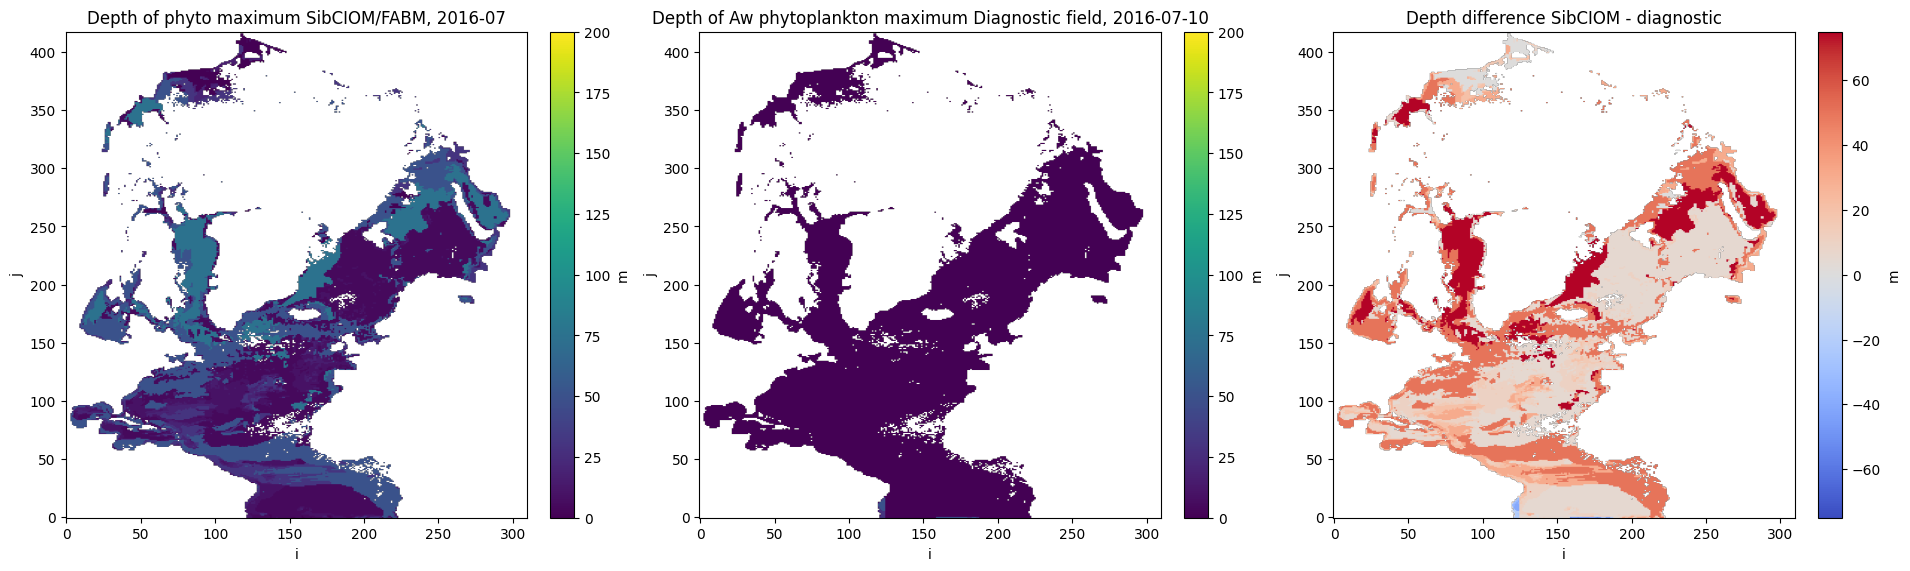

saved: pics/depth_max/depth_max_phyto_vs_chl_2016_07.png


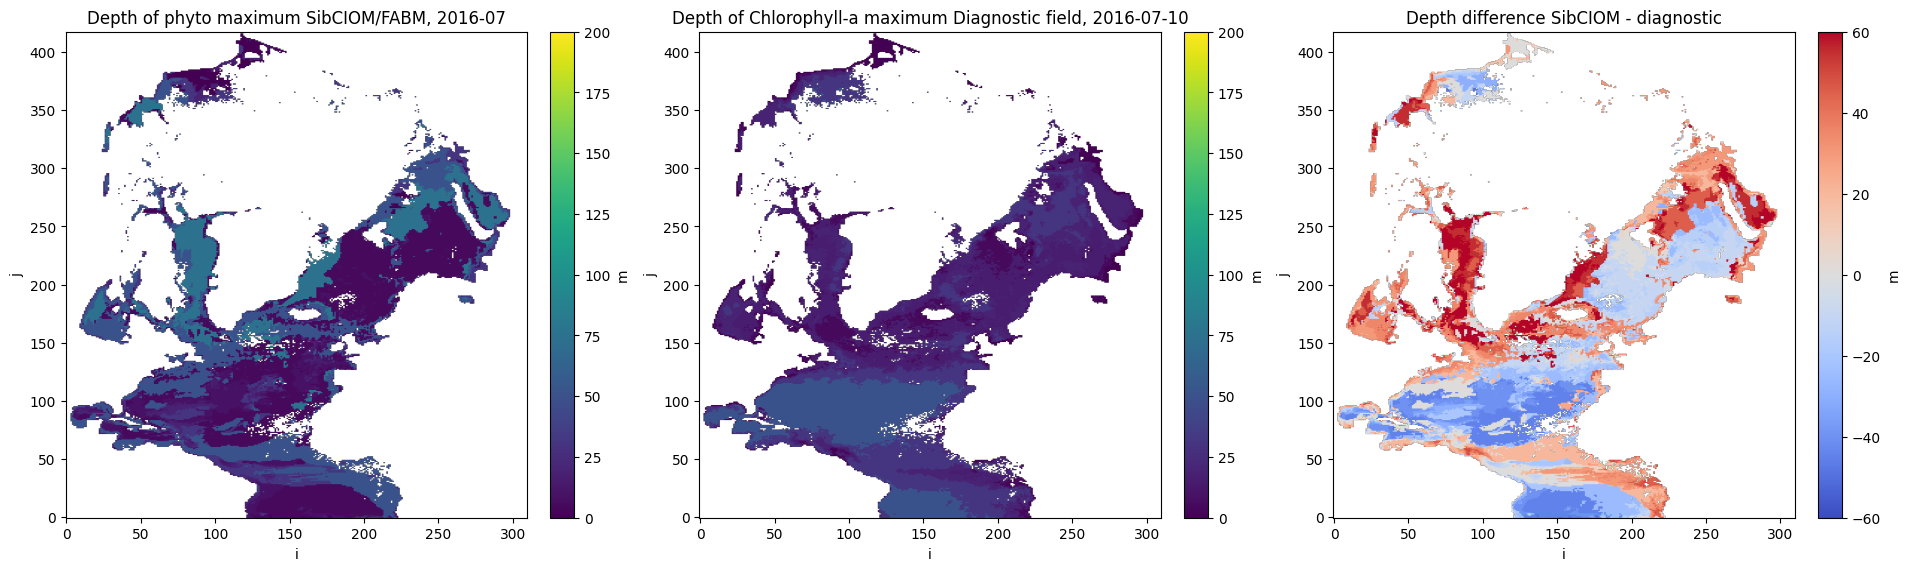

In [6]:
# -------------------------
# Main figure: maximum-depth comparison
# -------------------------
for obs_field_key, result in results_by_obs_key.items():
    obs_name = str(result["obs_name"])
    fig = plot_three_maps(result["model_depth_m"], result["obs_depth_m"], result["diff_depth_m"])
    if SAVE_FIGURES:
        out_path = OUT_DIR / f"depth_max_{MODEL_VAR_NAME}_vs_{obs_field_key}_{MODEL_YEAR:04d}_{MODEL_MONTH:02d}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print("saved:", out_path)
    plt.show()


saved: pics/depth_max/max_value_phyto_vs_Aw_2016_07.png


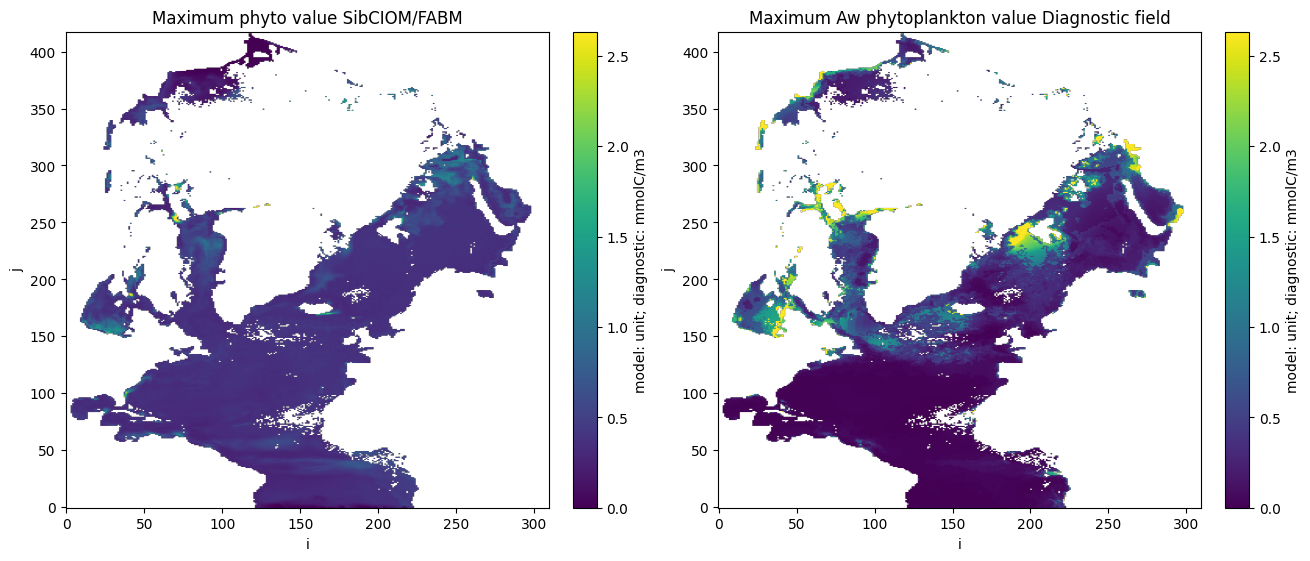

saved: pics/depth_max/max_value_phyto_vs_chl_2016_07.png


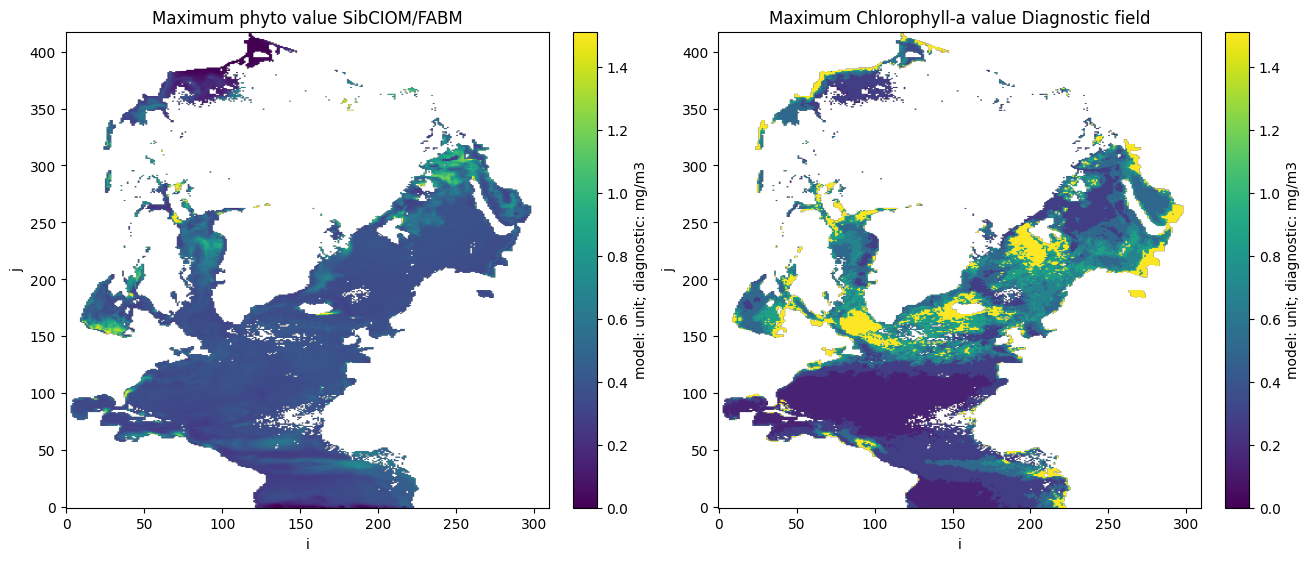

In [7]:
# -------------------------
# Optional: maximum-value maps
# These are not the primary validation plot, but useful for interpreting the depth maps.
# -------------------------
for obs_field_key, result in results_by_obs_key.items():
    obs_name = str(result["obs_name"])
    obs_units = str(result["obs_units"])
    fig = plot_two_maps(
        result["model_value_m"],
        result["obs_value_m"],
        title_left=f"Maximum {MODEL_VAR_NAME} value SibCIOM/FABM",
        title_right=f"Maximum {obs_name} value Diagnostic field",
        units=f"model: {model_units}; diagnostic: {obs_units}",
    )
    if SAVE_FIGURES:
        out_path = OUT_DIR / f"max_value_{MODEL_VAR_NAME}_vs_{obs_field_key}_{MODEL_YEAR:04d}_{MODEL_MONTH:02d}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print("saved:", out_path)
    plt.show()


In [8]:
# -------------------------
# Optional: pick representative points for profile plots
# -------------------------
def point_from_mask_stat(values: np.ndarray, mode: str) -> tuple[int, int]:
    arr = np.asarray(values, dtype=np.float64)
    if mode == "largest_abs_diff":
        score = np.abs(arr)
        idx = np.nanargmax(score)
    elif mode == "model_deeper":
        idx = np.nanargmax(arr)
    else:
        raise ValueError(mode)
    i, j = np.unravel_index(idx, arr.shape)
    return int(i), int(j)

points


{'largest_abs_diff': (12, 166), 'model_deeper': (12, 166)}

saved: pics/depth_max/profiles_depth_max_points_phyto_vs_Aw_2016_07.png


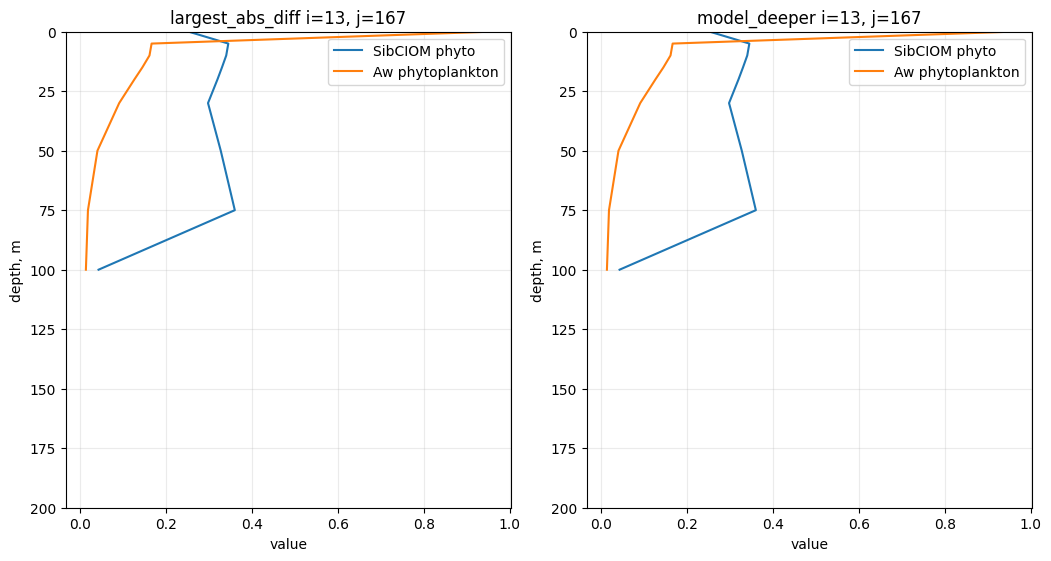

saved: pics/depth_max/profiles_depth_max_points_phyto_vs_chl_2016_07.png


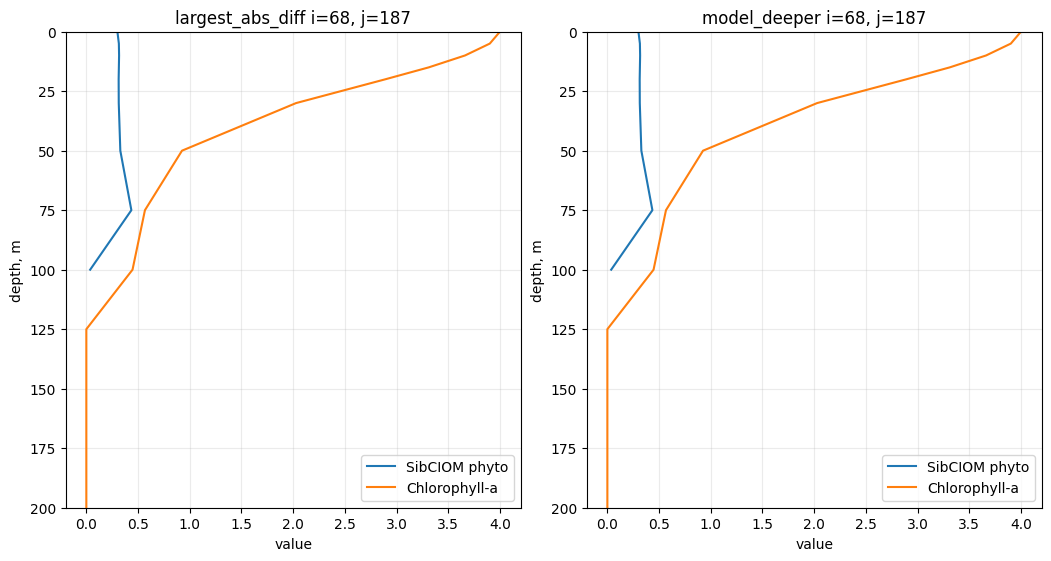

In [9]:
# -------------------------
# Optional: profile comparison in representative points
# -------------------------
def plot_profiles_at_points(
    points: dict[str, tuple[int, int]],
    obs_var_local: np.ndarray,
    obs_name_local: str,
    max_depth_m: float = 200.0,
) -> plt.Figure:
    n = len(points)
    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 5.5), constrained_layout=True)
    if n == 1:
        axes = [axes]

    depth_mask = np.isfinite(model_z) & (model_z <= max_depth_m)
    depth = model_z[depth_mask]

    for ax, (label, (i, j)) in zip(axes, points.items()):
        m_prof = model_var[i, j, depth_mask]
        o_prof = obs_var_local[i, j, depth_mask]
        ax.plot(m_prof, depth, label=f"SibCIOM {MODEL_VAR_NAME}")
        ax.plot(o_prof, depth, label=obs_name_local)
        ax.set_ylim(float(np.nanmax(depth)), float(np.nanmin(depth)))
        ax.set_xlabel("value")
        ax.set_ylabel("depth, m")
        ax.set_title(f"{label} i={i + 1}, j={j + 1}")
        ax.grid(True, alpha=0.25)
        ax.legend()
    return fig

for obs_field_key, result in results_by_obs_key.items():
    fig = plot_profiles_at_points(
        result["points"],
        np.asarray(result["obs_var"], dtype=np.float64),
        str(result["obs_name"]),
        max_depth_m=MAX_SEARCH_DEPTH_M,
    )
    if SAVE_FIGURES:
        out_path = OUT_DIR / f"profiles_depth_max_points_{MODEL_VAR_NAME}_vs_{obs_field_key}_{MODEL_YEAR:04d}_{MODEL_MONTH:02d}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print("saved:", out_path)
    plt.show()


In [10]:
# -------------------------
# Optional: export maps as NumPy arrays for later use
# -------------------------
for obs_field_key, result in results_by_obs_key.items():
    out_npz = OUT_DIR / f"depth_max_maps_{MODEL_VAR_NAME}_vs_{obs_field_key}_{MODEL_YEAR:04d}_{MODEL_MONTH:02d}.npz"
    np.savez_compressed(
        out_npz,
        model_depth=result["model_depth_m"],
        diagnostic_depth=result["obs_depth_m"],
        depth_difference=result["diff_depth_m"],
        model_max_value=result["model_value_m"],
        diagnostic_max_value=result["obs_value_m"],
        common_mask=result["common_mask"],
        h=h,
        z=model_z,
    )
    print("saved:", out_npz)


saved: pics/depth_max/depth_max_maps_phyto_vs_Aw_2016_07.npz
saved: pics/depth_max/depth_max_maps_phyto_vs_chl_2016_07.npz
